# 5주차 4차시: LLM 평가 시스템 심화

| 주제 | 내용 |
|---|---|
| 평가 방법 | Reference-based · Few-shot · Multidimensional · Ensemble |
| 편향 검출 | Length Bias Detection |
| 평가 검증 | 재현성(Reproducibility) · 판별력(Discriminability) |
| 기준 평가 | EvaluationCriterion 클래스 · criteria_evaluate |

In [1]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
import os
import re
import time
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import ContextualCompressionRetriever, EnsembleRetriever
from langchain_classic.retrievers.document_compressors import LLMChainExtractor
# from dotenv import load_dotenv
# load_dotenv()
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
MODEL = "gpt-4o-mini"
llm = ChatOpenAI(model=MODEL)
embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

## Reference-Based 평가

정답(Reference)이 있을 때 활용. LLM이 정답과 답변을 비교해 평가:

1. 정답의 핵심 포인트 포함 여부
2. 사실적 오류 유무
3. 정답에 없는 올바른 추가 정보 여부

In [3]:
def reference_based_judge(question, reference, answer):
    prompt = f"""당신은 AI 교육 전문가입니다.
    정답을 기준으로 학생의 답변을 평가하세요.

    질문 : {question}
    정답 : {reference}
    학생 답변 : {answer}

    평가 기준:
    - 정답의 핵심 포인트를 얼마나 포함하는가
    - 사실적으로 틀린 내용이 있는가
    - 정답에 없는 올바른 추가 정보가 있는가

    JSON으로 답하세요:
    {{"score": 1-5, "covered_points" : ["포함된 핵심 포인트들"], "missing_points":["누락된 포인트들"], "errors" : ["틀린 내용"]}}"""

    result = llm.invoke(prompt).content
    cleaned = result.replace('```json', '').replace('```', '')
    return json.loads(cleaned)

In [ ]:
question = "객체지향 프로그래밍의 4대 원칙을 설명해주세요"
answer = "캡슐화, 상속, 다형성이 있습니다. 캡슐화는 데이터를 숨기는 것이고 상속은 부모 클래스를 물려받는 것입니다."

## Few-shot 평가

평가 예시(shot = example)를 프롬프트에 포함해 LLM의 평가 기준을 안내.

- 좋은 답변 예시 (점수 4) + 나쁜 답변 예시 (점수 2)를 제공
- LLM이 예시의 패턴을 학습해 일관성 있는 평가 수행

In [6]:
question = "Git이란 무엇인가요?"
answer = "코드 버전 관리 도구입니다."

In [8]:
def fewshot_judge(question, answer):
  prompt = f"""당신은 10년차 프로그래머입니다.
  예시를 이용하여 학생의 답변을 1-5점으로 평가하세요.

  === 평가예시 ===

  질문: 파이썬 리스트란?
  답변: 파이썬 리스트는 순서가 있는 변경 가능한 컬렉션입니다. []로 생성하며 다양한 타입을 저장할 수 있습니다.
  점수: 4
  이유: 핵심 특성(순서, 변경가능)을 정확히 설명. 메서드 예시가 있었으면 5점.

  질문: 변수란 무엇인가요?
  답변: 값을 저장하는 것
  점수: 2
  이유: 맞지만 너무 짧고 구체적 설명이 부족.

  === 실제 평가 ===
  질문 : {question}
  답변 : {answer}

   JSON으로 답하세요:
    {{"score": 1-5,
    "reasoning": "이유"
    "covered_points" : ["포함된 핵심 포인트들"],
    "missing_points":["누락된 포인트들"],
    "errors" : ["틀린 내용"]}}"""

  result = llm.invoke(prompt).content
  cleaned = result.replace('```json', '').replace('```', '')
  return json.loads(cleaned)




In [9]:
fewshot_judge(question, answer)

{'score': 3,
 'reasoning': 'Git이 코드 버전 관리 도구라는 기본적인 개념을 언급했지만, 더 많은 세부사항이 부족합니다. 성격, 사용 목적 및 기능에 대한 추가 설명이 필요합니다.',
 'covered_points': ['코드 버전 관리 도구'],
 'missing_points': ['Git의 특징', '분산형 버전 관리', '협업 지원 기능'],
 'errors': []}

### 평가 방법별 시간 복잡도

| 방법 | 복잡도 | 비고 |
|---|---|---|
| pairwise | O(N²) | 모든 답변 쌍을 비교 |
| cot_judge | O(N) | 답변당 1회 호출 |
| reference_based | O(N) | 답변당 1회 호출 |
| fewshot_judge | O(N) | 답변당 1회 호출 |

## 다차원 평가 (Multidimensional Judge)

답변을 여러 차원에서 개별 평가. 단일 점수보다 세밀한 분석 가능.

| 차원 | 설명 |
|---|---|
| accuracy | 내용이 정확한 정도 |
| relevance | 답변이 질문과 관련 있는 정도 |
| completeness | 핵심 포인트가 포함된 정도 |
| coherence | 답변의 논리적 일관성 |
| practicality | 실무 응용 가능성 |

In [20]:
EVAL_DIMENSIONS = {
    "accuracy": "사실적으로 정확한 정보만 포함하는가 (1-5)",
    "relevance": "질문의 의도와 범위에 적합한 답변인가 (1-5)",
    "completeness": "핵심 포인트를 빠짐없이 다루는가 (1-5)",
    "coherence": "논리적 흐름과 구조가 일관적인가 (1-5)",
    "practicality": "답변이 얼마나 실용적이며 실무와 관련 있는가 (1-5)"
}

In [21]:
def multidim_judge(question, answer, dimensions = EVAL_DIMENSIONS):
  dim_text = '\n'.join(f" - {k} : {v}" for k, v in dimensions.items())
  dim_keys = list(dimensions.keys())

  prompt = f"""다음 답변을 아래 차원별로 독립적으로 평가하세요.
  각 차원은 다른 차원에 영향을 받지 않고 독립 평가합니다.

  질문 : {question}
  답변 : {answer}

  평가 차원:
  {dim_text}

  JSON으로 답하세요:
  {{"scores": {{{".".join(f'"{k}": 1-5' for k in dim_keys )}}}, "summary": "한 줄 요약}} """

  result = llm.invoke(prompt).content
  cleaned = result.replace('```json', '').replace('```', '')
  return json.loads(cleaned)


In [13]:
question = "머신러닝과 딥러닝의 차이점을 설명해주세요"
answers = [
    ("머신러닝은 데이터에서 패턴을 학습하는 넓은 개념이고, 딥러닝은 그 중 다층 신경망을 사용하는 방법입니다. 머신러닝에는 SVM, 결정트리 등이 있고, 딥러닝에는 CNN, RNN 등이 있습니다.", "완전한 답변"),
    ("둘 다 AI 기술입니다. 딥러닝이 더 발전된 기술입니다.", "불완전 답변"),
]

In [14]:
for ans, label in answers:
  result = multidim_judge(question, ans)
  scores = result.get("scores")
  print(scores, result.get('summary'))

{'accuracy': 5, 'relevance': 5, 'completeness': 4, 'coherence': 5} 머신러닝과 딥러닝의 차이를 명확히 설명하였으며, 관련된 예시를 통해 이해를 돕고 있습니다.
{'accuracy': 2, 'relevance': 2, 'completeness': 1, 'coherence': 3} 답변은 정보가 부족하고 질문에 대한 명확한 차이를 설명하지 못함.


### 레이더 차트 시각화

다차원 평가 결과를 레이더(방사형) 차트로 시각화. 각 차원의 점수를 한눈에 비교 가능.

In [18]:
def plot_radar(scores_dict, title='multi-dim evaluation'): # 위와같이 다차원 평가 플롯
  categories = list(scores_dict.keys())
  values = list(scores_dict.values())
  values += values[:1]

  # 카테고리 개수만큼 그래프의 속성(항목)별 각도를 나눔
  angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
  angles += angles[:1]

  fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
  ax.fill(angles, values, alpha = 0.25)
  ax.plot(angles, values, 'o-', linewidth=2)
  ax.set_xticks(angles[:-1])
  ax.set_xticklabels(categories)
  ax.set_ylim(0, 5)
  ax.set_title(title, pad=20)
  plt.show()

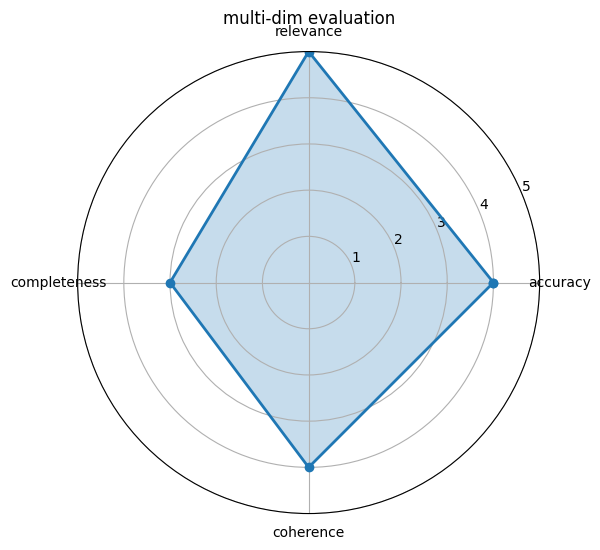

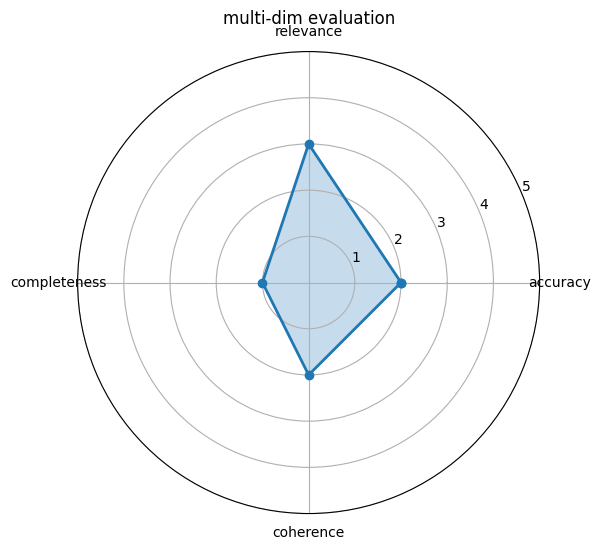

In [19]:
for ans, label in answers:
    result = multidim_judge(question, ans)
    scores = result.get("scores")
    plot_radar(scores)

## LLM 평가의 편향 문제

LLM 기반 평가 시 주의해야 할 3가지 편향:

1. **길이 편향**: 긴 답변에 더 높은 점수를 주는 경향
2. **평가 불균형**: 각 답변이 다른 방식으로 작성된 경우 편향 발생
3. **자기 강화 편향**: LLM이 자기가 생성한 답변에 더 높은 점수를 부여

해결 방법: 다양한 평가 함수의 앙상블, 다른 모델로 교차 검증 등

### 길이 편향 검출 (Length Bias Detection)

짧은 답변과 긴 답변의 pointwise 점수 차이를 측정.  
`bias = long_score - short_score` → 양수면 길이 편향 존재 가능.

In [34]:
RUBRIC = {
    5: "정확하고 완전하며, 예시와 설명이 풍부하다",
    4: "정확하고 핵심을 다루지만, 일부 세부사항이 부족하다",
    3: "대체로 정확하지만, 중요한 내용 일부가 누락되었다",
    2: "부분적으로만 정확하거나, 핵심을 빗나갔다",
    1: "부정확하거나 질문과 무관하다",
}
def pointwise_judge(question, answer, rubric = RUBRIC):
    rubric_text = '\n'.join(
        f' {k} 점: {v}' for k, v in sorted(rubric.items(), reverse=True)
    )

    prompt = f"""다음 답변을 아래 루브릭에 따라 평가해주세요.

    질문 : {question}
    답변 : {answer}

    루브릭 :
    {rubric_text}

    반드시 JSON으로 답하세요:
    {{"score": 1-5, "reasoning" : "이유"}}"""

    result = llm.invoke(prompt).content
#     print(result)
    result = result.replace('```json', '').replace('```', '')
    return json.loads(result)

In [33]:
def detect_length_bias(question, short_answer, long_answer):
  short_result = pointwise_judge(question, short_answer)
  long_result = pointwise_judge(question, long_answer)

  short_score = short_result.get('score')
  long_score = long_result.get('score')

  bias = long_score - short_score

  return {
      'short_score' : short_score,
      'long_score' : long_score,
      'bias' : bias,
      'short_len' : len(short_answer),
      'long_len' : len(long_answer),
      'has_bias' : bias > 0

  }

In [45]:
question = "파이썬 GIL이란?"
short = "GIL은 한 번에 하나의 스레드만 파이썬 바이트코드를 실행하도록 제한하는 뮤텍스입니다."
long = "GIL(Global Interpreter Lock)은 CPython 인터프리터에서 사용되는 메커니즘입니다. GIL은 한 번에 하나의 스레드만 파이썬 바이트코드를 실행하도록 제한하는 뮤텍스(mutual exclusion lock)입니다. 이는 메모리 관리의 thread-safety를 위해 도입되었으나, 멀티스레드 프로그램의 병렬 실행을 제한하는 단점이 있습니다. 이를 우회하기 위해 multiprocessing 모듈을 사용하거나, I/O 바운드 작업에서는 asyncio를 활용할 수 있습니다."
#long = "GIL은 한 번에 하나의 스레드만 파이썬 바이트코드를 실행하도록 제한하는 뮤텍스입니다. 스레드만 파이썬 바이트코드를 실행하도록 제한하는 뮤텍스입니다. 스레드만 파이썬 바이트코드를 실행하도록 제한하는 뮤텍스입니다."

In [42]:
result = detect_length_bias(question, short, long)

In [50]:
result

{'short_score': 4,
 'long_score': 2,
 'bias': -2,
 'short_len': 48,
 'long_len': 118,
 'has_bias': False}

## 앙상블 평가 (Ensemble Judge)

여러 평가 함수의 점수를 통합해 편향을 줄이고 안정성 향상.

| 집계 방식 | 설명 |
|---|---|
| mean | 단순 평균 |
| median | 중앙값 (이상치에 강건) |
| trimmed mean | 최대/최소 제거 후 평균 |
| weighted mean | 가중 평균 (신뢰도 높은 함수에 가중치 부여) |

In [53]:
def ensemble_judge(question, answer, judge_fns, weights = None):
  scores = []
  for name, fn in judge_fns: # 신기함, ("pointwise" ,pointwise_judge),처럼 명시하면
                              # fn에 해당하는 함수가, 아래의
    result = fn(question, answer) # fn에 대체되어 함수를 실행함
    score = result.get('score')
    scores.append(score)
    print(f"{name} : {score}")

  mean_score = np.mean(scores)
  median_score = np.median(scores)

  # 절삭평균 : 최대값, 최소값을 제외한 나머지의 평균
  if len(scores) >= 3:
    sorted_scores = sorted(scores)
    trimmed_scores = sorted_scores[1:-1]
    trimmed_mean = np.mean(trimmed_scores)
  else:
    trimmed_mean = mean_score

  # 가중평균 : weight에 따라서 스코어를 곱해주는것
  if weights is not None and len(weights) == len(scores):
    weighted_mean = np.average(scores, weights=weights) # 곱해준 후 평균

  return {
      'mean_score' : mean_score,
      'median_score' : median_score,
      'trimmed_score' : trimmed_mean,
      'weighted_score' : weighted_mean,
  }

In [55]:
judge_fns = {
    ("pointwise" ,pointwise_judge),
   # ("CoT ", cot_judge),
    ('Few-shot', fewshot_judge)

}

question = "API 게이트웨이란?"
answer = "API 게이트웨이는 클라이언트와 백엔드 서비스 사이의 중간 계층으로, 인증, 라우팅, 속도 제한 등을 처리합니다."

result = ensemble_judge(question, answer, judge_fns, weights = [1, 2])
result



Few-shot : 4
pointwise : 4


{'mean_score': np.float64(4.0),
 'median_score': np.float64(4.0),
 'trimmed_score': np.float64(nan),
 'weighted_score': np.float64(4.0)}

## 평가 시스템 검증

LLM 평가 시스템 자체의 품질을 검증하는 방법.

- **재현성 (Reproducibility)**: 같은 입력에 대해 점수가 얼마나 일관적인지
- **판별력 (Discriminability)**: 좋은 답변과 나쁜 답변을 구분할 수 있는지
- **신뢰도**: 전문가 평가(human)와 LLM 점수 간 일치도 (상관계수)

### 재현성 테스트 (Reproducibility)

동일 입력을 n_trials회 반복 평가 → 점수의 평균, 표준편차, 변동계수(CV) 측정.  
CV가 낮을수록 평가가 안정적.

In [58]:
def test_reproductbility(question, answer, n_trials = 5):
  scores = []
  for i in range(n_trials):
    result = pointwise_judge(question, answer)
    score = result.get('score')
    scores.append(score)
  # [3, 4, 4, 4, 5] 등의 scores

  mean = np.mean(scores)
  std = np.std(scores)
  cv = std / mean if mean > 0 else float('inf') # 변동계수를 cv라고 함

  return {'scores' : scores, 'mean': mean, 'std':std, 'cv':cv}


In [59]:
question = "REST API란?"
answer = "REST는 HTTP 프로토콜을 사용하여 리소스를 CRUD 방식으로 관리하는 아키텍처 스타일입니다."

In [60]:
test_reproductbility(question, answer, n_trials=5)

{'scores': [4, 4, 4, 4, 4],
 'mean': np.float64(4.0),
 'std': np.float64(0.0),
 'cv': np.float64(0.0)}

### 판별력 테스트 (Discriminability)

좋은 답변과 나쁜 답변의 평균 점수 차이(gap) 측정.  
`gap > 1.5`이면 판별력이 충분한 것으로 판단.

In [62]:
def test_discriminability(question, good_answer, bad_answer, n_trials = 3):
  good_scores = []
  bad_scores = []

  for _ in range(n_trials):
    good_r = pointwise_judge(question, good_answer)
    bad_r = pointwise_judge(question, bad_answer)
    good_scores.append(good_r.get('score'))
    bad_scores.append(bad_r.get('score'))

  gap = np.mean(good_scores) - np.mean(bad_scores)

  return {
      'good_mean' : np.mean(good_scores),
      'bad_mean' : np.mean(bad_scores),
      'gap' : gap,
      'discriminable' : gap > 1.5
  }

In [63]:
test_discriminability(
    "데이터베이스 인덱스란?",
    "데이터베이스 인덱스는 테이블 검색 속도를 높이기 위한 자료구조입니다. B-Tree, Hash 등의 구조를 사용하며, SELECT 쿼리 성능을 크게 향상시킵니다.",
    "데이터베이스에 있는 것입니다."
)

{'good_mean': np.float64(4.0),
 'bad_mean': np.float64(1.0),
 'gap': np.float64(3.0),
 'discriminable': np.True_}

## 기준 기반 평가 (Criteria Evaluation)

평가 기준을 객체로 정의해 재사용 가능한 구조화된 평가 시스템 구축.

- `EvaluationCriterion`: 기준명, 설명, 점수 범위를 캡슐화
- `criteria_evaluate`: 특정 기준에 따라 LLM에게 답변 평가 요청

In [66]:
class EvaluationCriterion:
  def __init__(self, name, description, scale = (1,5)):
    self.name = name
    self.description = description
    self.scale = scale

  def __repr__(self):
    return f"Criterion({self.name}: {self.description}, {self.scale[0]} - {self.scale[1]})"


In [67]:
STANDARD_CRITERIA = [
    EvaluationCriterion("accuracy",     "사실적으로 정확한 정보만 포함하는가"),
    EvaluationCriterion("relevance",    "질문의 의도와 범위에 적합한 답변인가"),
    EvaluationCriterion("completeness", "핵심 포인트를 빠짐없이 다루는가"),
    EvaluationCriterion("coherence",    "논리적 흐름과 구조가 일관적인가"),
]

In [69]:
print(EvaluationCriterion("coherence",    "논리적 흐름과 구조가 일관적인가"))

Criterion(coherence: 논리적 흐름과 구조가 일관적인가, 1 - 5)


In [78]:
def criteria_evaluate(question, answer, criterion):
    prompt = f"""당신은 전문 평가자입니다.
    아래 기준에 따라 답변을 {criterion.scale[0]}-{criterion.scale[1]} 스케일로 평가하세요.

    질문 : {question}
    답변 : {answer}

    평가 기준 [{criterion.name}] : {criterion.description}

    JSON으로 답하세요:
    {{"score" : {criterion.scale[0]}-{criterion.scale[1]}}}"""

    result = llm.invoke(prompt).content

    cleaned = result.strip()

    if cleaned.startswith("```"):
        cleaned = cleaned.split("```")[1].replace("json", "")

    return json.loads(cleaned)

In [79]:
question = "도커(Docker)의 장점을 설명해주세요"
answer = "도커는 컨테이너 기술로 애플리케이션을 격리된 환경에서 실행합니다. 가볍고 빠르며, 환경 일관성을 보장합니다."

In [80]:

for criterion in STANDARD_CRITERIA:
  result = criteria_evaluate(question,answer, criterion)
  print(f"{criterion.name} : {result.get('score')}")

accuracy : 4
relevance : 4
completeness : 4
coherence : 4
